<a href="https://colab.research.google.com/github/karthik-1219/IPL-Data-Analysis-Project/blob/main/IPL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# setting style

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [5]:
# loading datasets

deli = pd.read_csv('/content/IPL Data Analysis/deliveries.csv')
mat = pd.read_csv('/content/IPL Data Analysis/matches.csv')

In [6]:
# deliveries.csv dataset size and first 5 rows

deli.shape

(260920, 17)

In [7]:
deli.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [8]:
# match.csv dataset size and first 5 rows

mat.shape

(1095, 20)

In [9]:
mat.head(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [10]:
# mat['city'].value_counts()
# mat['venue'].value_counts()
mat['team1'].value_counts()

,count
team1,
Royal Challengers Bangalore,135
Chennai Super Kings,128
Mumbai Indians,123
Kolkata Knight Riders,121
Rajasthan Royals,101
Kings XI Punjab,92
Sunrisers Hyderabad,86
Delhi Daredevils,85
Delhi Capitals,41


In [11]:
# team names issues in datasets

deli['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,31437
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Royal Challengers Bangalore,28205
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


In [12]:
# resolving naming issues in deliveries.csv i.e, batting_team , bowling_team

deli['batting_team'] = deli['batting_team'].replace({'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'})
deli['bowling_team'] = deli['bowling_team'].replace({'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'})

deli['batting_team'] = deli['batting_team'].replace({'Rising Pune Supergiant': 'Rising Pune Supergiants'})
deli['bowling_team'] = deli['bowling_team'].replace({'Rising Pune Supergiant': 'Rising Pune Supergiants'})

In [13]:
deli.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [14]:
deli['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,31437
Royal Challengers Bengaluru,30023
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


In [15]:
# resolving naming issues in matches.csv i.e, city , venue , team1 , team2 , toss_winner , winner

# city replacements
city_replacements = {
    'Bangalore': 'Bengaluru',
    'Chandigarh': 'Mohali',
    'Navi Mumbai': 'Mumbai'
}

mat['city'] = mat['city'].replace(city_replacements)


# venue name replacements
venue_replacements = {
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'Punjab Cricket Association Stadium',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam': 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium',
    'Barsapara Cricket Stadium, Guwahati': 'Barsapara Cricket Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'Himachal Pradesh Cricket Association Stadium',
    'Vidarbha Cricket Association Stadium, Jamtha': 'Vidarbha Cricket Association Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur': 'Maharaja Yadavindra Singh International Cricket Stadium',
}

mat['venue'] = mat['venue'].replace(venue_replacements)


# team1 , team2 , toss_winner , winner replacements
team_replacements = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

for i in ['team1', 'team2', 'toss_winner', 'winner']:
    mat[i] = mat[i].replace(team_replacements)


In [16]:
mat.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bengaluru,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Mohali,2008-04-19,League,MEK Hussey,Punjab Cricket Association Stadium,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [17]:
# total NA values in city
mat['city'].isna().sum()


np.int64(51)

In [18]:
# fix NA
mat['city'] = mat['city'].fillna('Unknown')

In [19]:
# D/L in method
mat['method'].value_counts()


,count
method,
D/L,21


In [20]:
# change NaN or NA to Non D/L
mat['method'] = mat['method'].fillna('Non D/L')

In [21]:
def random_colors(no_of_colors):
    return ['#'+''.join([np.random.choice(list('0123456789ABCDEF')) for _ in range(6)]) for _ in range(no_of_colors)]

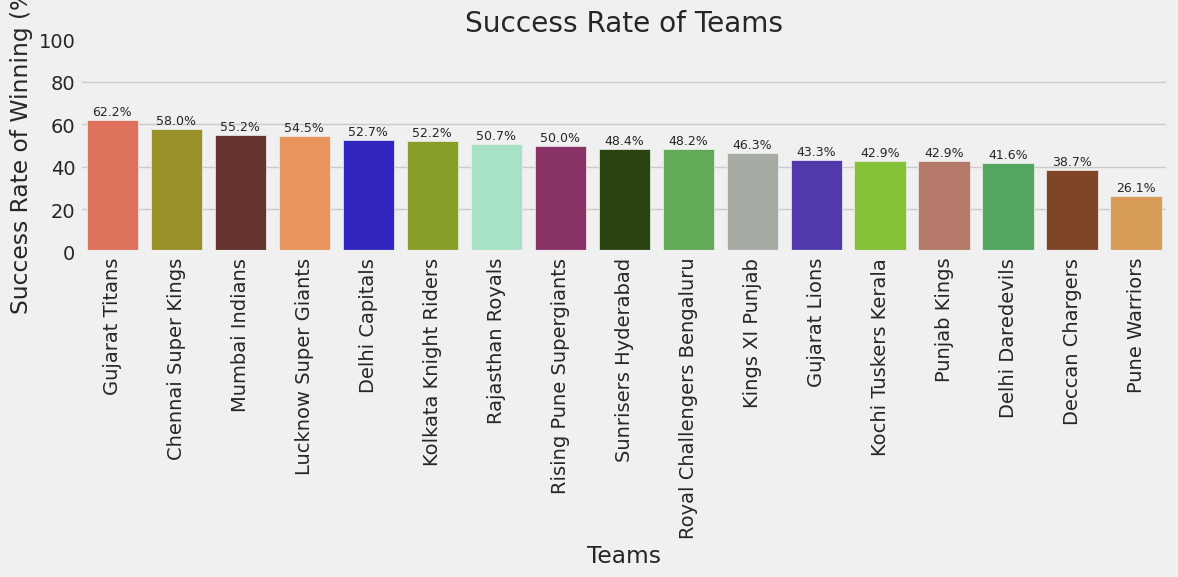

In [22]:
# Calculate success ratio correctly
wins = mat['winner'].value_counts()
matches_played = mat['team1'].value_counts() + mat['team2'].value_counts()
sr = (wins / matches_played) * 100
sr = sr.sort_values(ascending=False)

# Plot a figure
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=sr.index, y=sr.values, hue=sr.index, palette=random_colors(len(sr)), legend=False)
plt.title('Success Rate of Teams')
plt.xlabel('Teams')
plt.ylabel('Success Rate of Winning (%)')
plt.xticks(rotation=90)
plt.ylim(0, 100)

for i, v in enumerate(sr.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


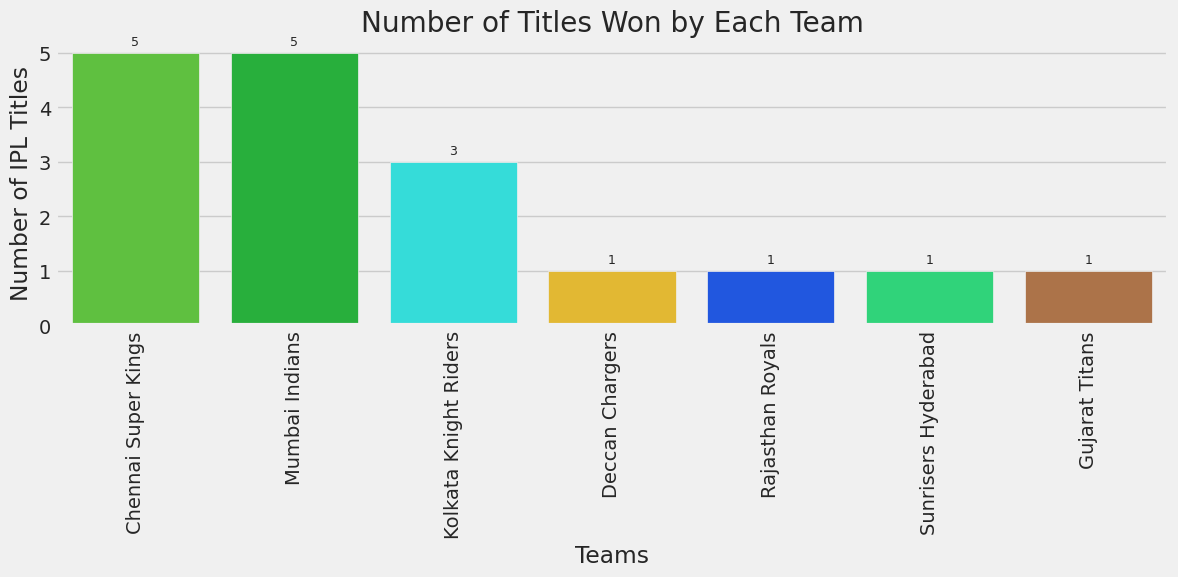

In [23]:
# Get winner count of each team by picking last match winner of each season
wc = mat.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()

# Plot a figure
plt.figure(figsize=(12, 6))

# Use barplot with correct x and y directly from Series (no hue needed)
ax = sns.barplot(x=wc.index, y=wc.values,hue=wc.index, palette=random_colors(len(wc)), legend=False)

plt.title('Number of Titles Won by Each Team')
plt.xlabel('Teams')
plt.ylabel('Number of IPL Titles')
plt.xticks(rotation=90)

# Correct loop for adding value labels
for i, v in enumerate(wc.values):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


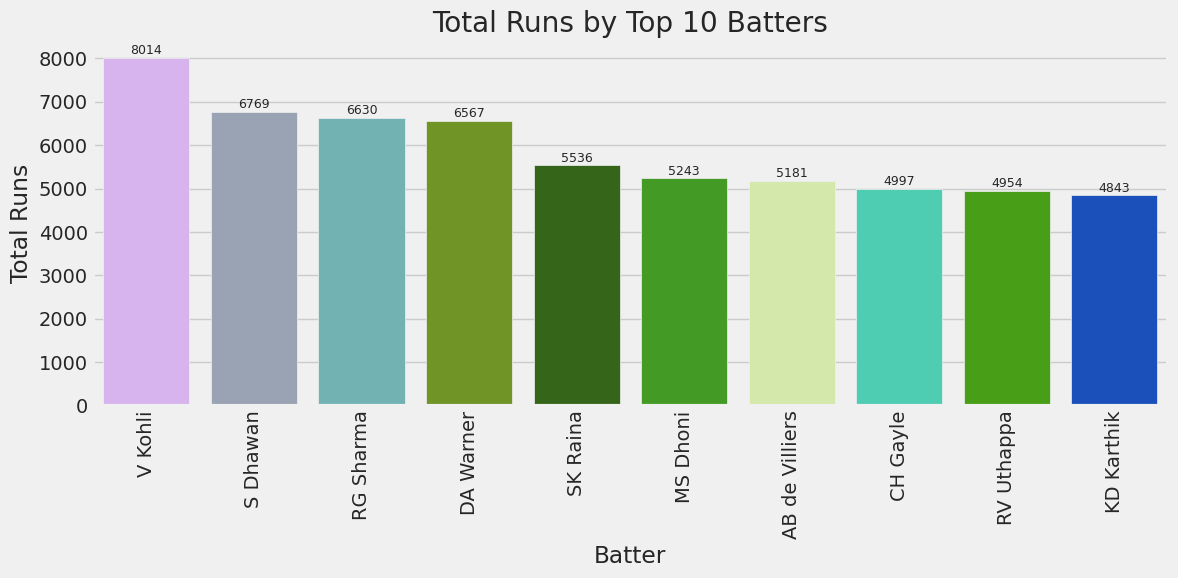

In [24]:
# Calculate total runs
tot_runs = deli.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')
top10_runs = tot_runs.sort_values(by='Runs', ascending=False).head(10)

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='batter', y='Runs',hue='batter', data=top10_runs,palette=random_colors(len(top10_runs)), legend=False)

plt.title('Total Runs by Top 10 Batters')
plt.xlabel('Batter')
plt.ylabel('Total Runs')
plt.xticks(rotation=90)

# Add value labels
for i, v in enumerate(top10_runs['Runs']):
    ax.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [25]:
ings_runs = deli.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')
top10_ings_runs = ings_runs.sort_values(by='Innings Runs', ascending=False).head(10)

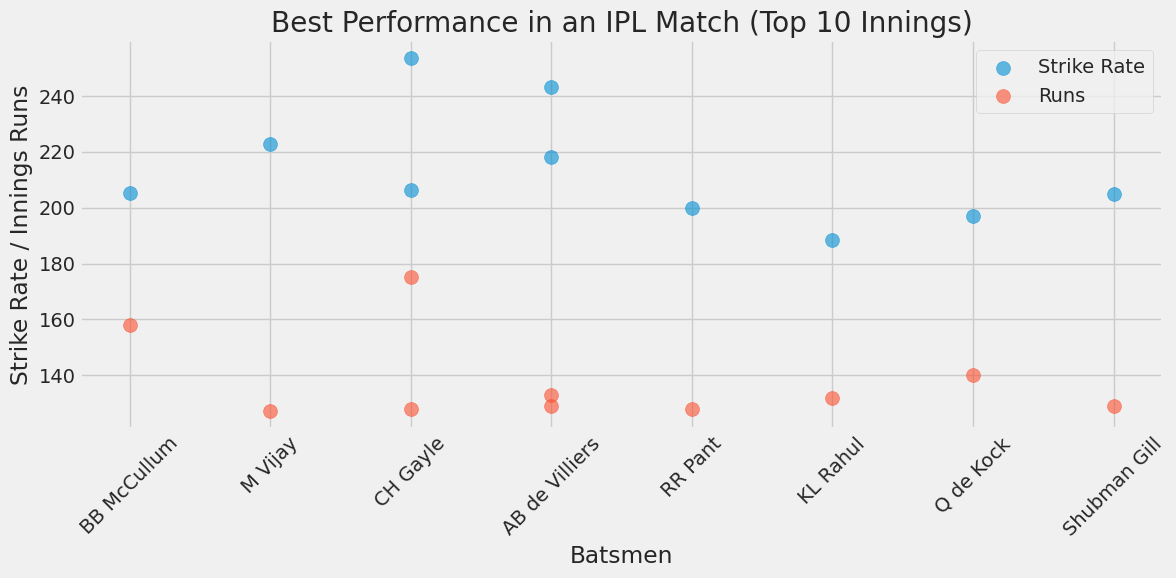

In [26]:
# bm_perf = batsman_performonce
balls_faced = deli.groupby(['match_id', 'batter'])['batsman_runs'].count().reset_index(name='Balls Faced')

bm_perf = pd.merge(ings_runs, balls_faced, how='inner', on=['match_id', 'batter'])
bm_perf['Strike Rate for Match'] = np.round(bm_perf['Innings Runs'] * 100 / bm_perf['Balls Faced'], 2)

# Filter bm_perf to keep only the exact rows from top10_ings_runs (match_id and batter)
bm_perf_top10 = bm_perf[bm_perf.set_index(['match_id', 'batter']).index.isin(top10_ings_runs.set_index(['match_id', 'batter']).index)]

plt.figure(figsize=(12, 6))
plt.scatter(bm_perf_top10['batter'], bm_perf_top10['Strike Rate for Match'], label='Strike Rate', s=100, alpha=0.6)
plt.scatter(bm_perf_top10['batter'], bm_perf_top10['Innings Runs'], label='Runs', s=100, alpha=0.6)
plt.title('Best Performance in an IPL Match (Top 10 Innings)')
plt.xlabel('Batsmen')
plt.ylabel('Strike Rate / Innings Runs')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

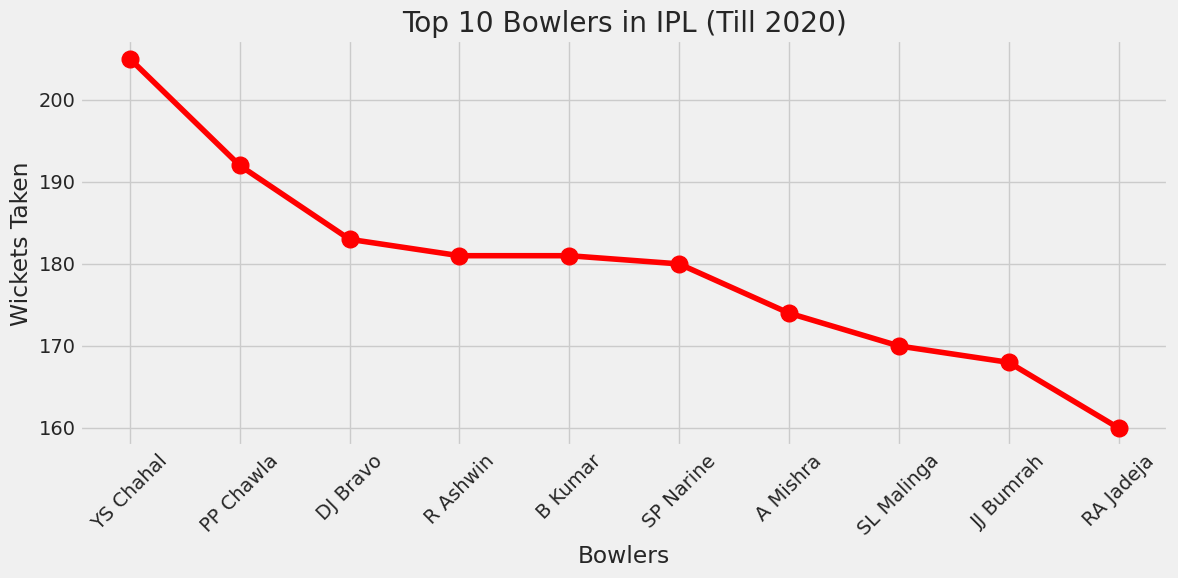

In [27]:
# bw = bowling_wickets

bw = deli[deli['dismissal_kind'] != 'run out']
top_bwlrs = bw.groupby('bowler')['dismissal_kind'].count().reset_index(name='wickets').sort_values(by='wickets', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.plot(top_bwlrs['bowler'], top_bwlrs['wickets'], marker='o', color='red', ms=12)
plt.title('Top 10 Bowlers in IPL (Till 2020)')
plt.xlabel('Bowlers')
plt.ylabel('Wickets Taken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


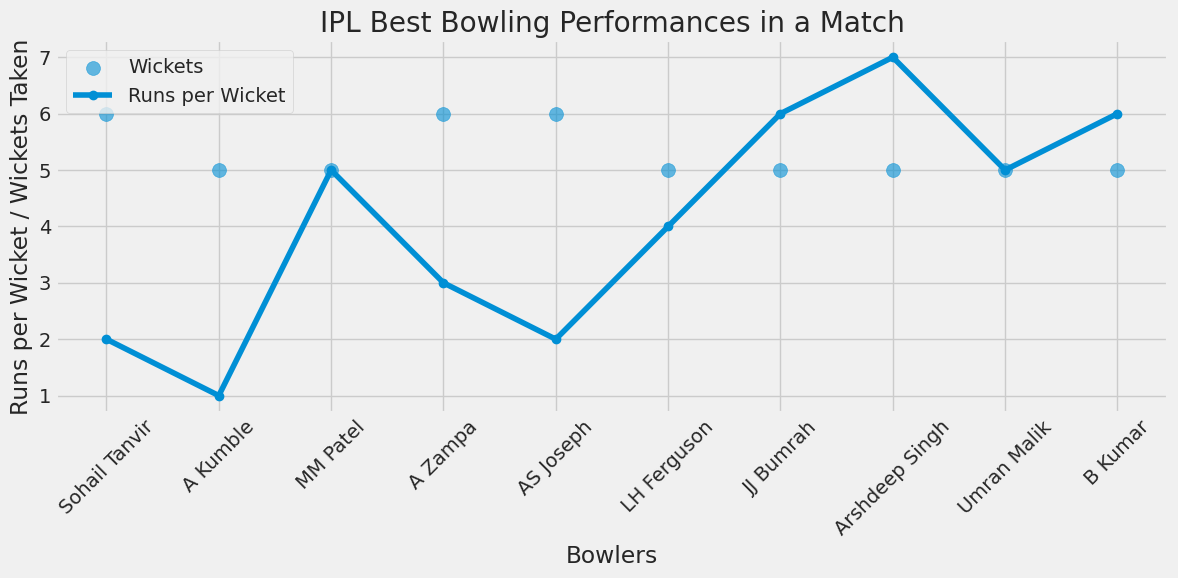

In [28]:
bw_wickets = bw.groupby(['match_id', 'bowler'])['dismissal_kind'].count().reset_index(name='wickets').sort_values(by='wickets', ascending=False)[:10]
bw_runs = deli.groupby(['match_id', 'bowler'])['total_runs'].sum().reset_index(name='runs_conceded')
bw_perf = pd.merge(bw_runs, bw_wickets, how='inner', on=['match_id', 'bowler'])
bw_perf['runs_per_wicket'] = np.round(bw_perf['runs_conceded'] / bw_perf['wickets'], 0)

plt.figure(figsize=(12, 6))
plt.scatter(bw_perf['bowler'], bw_perf['wickets'], label='Wickets', s=100, alpha=0.6)
plt.plot(bw_perf['bowler'], bw_perf['runs_per_wicket'], marker='o', label='Runs per Wicket')
plt.title('IPL Best Bowling Performances in a Match')
plt.xlabel('Bowlers')
plt.ylabel('Runs per Wicket / Wickets Taken')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
mat = mat.rename(columns={'id': 'match_id'})
deli_season = deli.merge(mat[['match_id', 'season']], on='match_id', how='left')


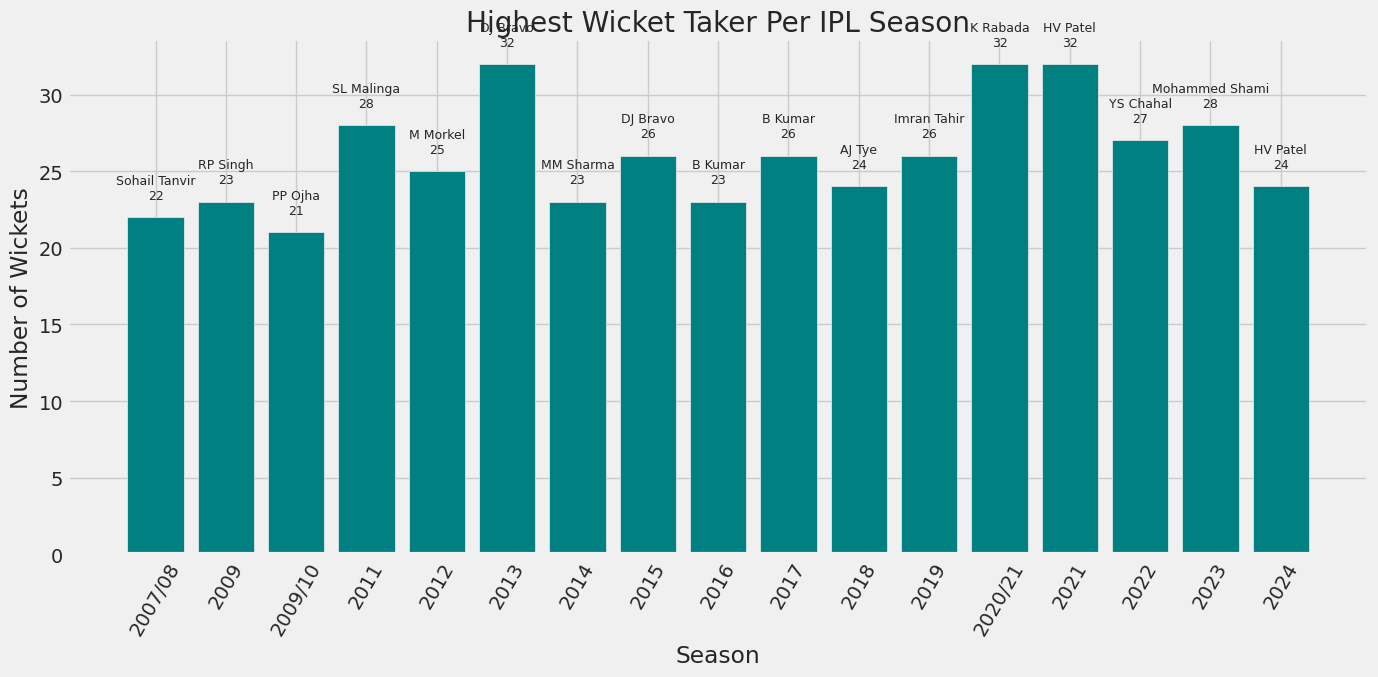

In [30]:
wickets = deli_season[deli_season['dismissal_kind'] != 'run out']
season_bowler_wickets = wickets.groupby(['season', 'bowler'])['dismissal_kind'].count().reset_index(name='wickets')
top_wicket_takers = season_bowler_wickets.loc[season_bowler_wickets.groupby('season')['wickets'].idxmax()]

plt.figure(figsize=(14,7))
bars = plt.bar(top_wicket_takers['season'].astype(str), top_wicket_takers['wickets'], color='teal')
plt.title('Highest Wicket Taker Per IPL Season')
plt.xlabel('Season')
plt.ylabel('Number of Wickets')
plt.xticks(rotation=60)

for bar, bowler, wickets in zip(bars, top_wicket_takers['bowler'], top_wicket_takers['wickets']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{bowler}\n{wickets}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


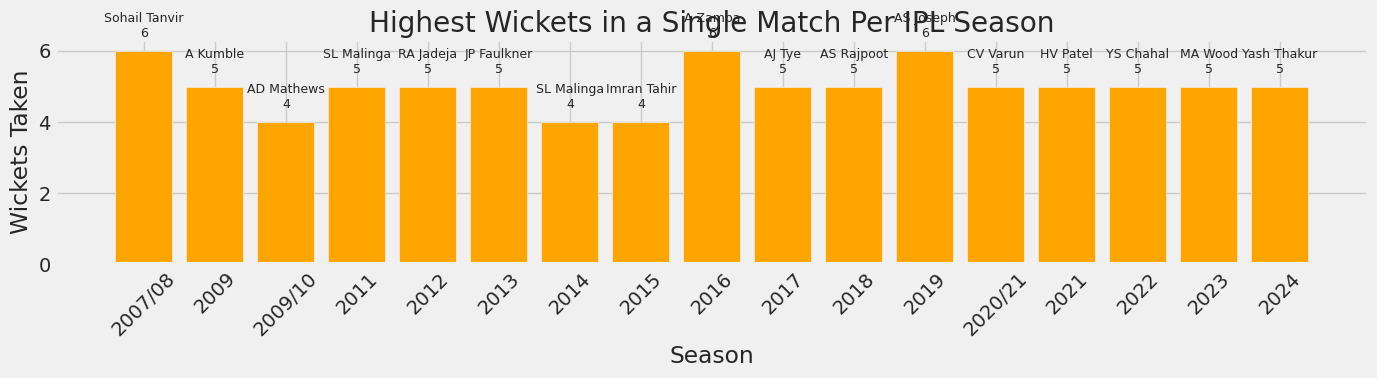

In [31]:
bw_wkts = deli[deli['dismissal_kind'] != 'run out']
bw_match = bw_wkts.groupby(['match_id', 'bowler'])['dismissal_kind'].count().reset_index(name='wkts')

bw_match = pd.merge(bw_match, mat[['match_id', 'season']], on='match_id', how='left')

bw_max_match = bw_match.sort_values(['season', 'wkts'], ascending=[True, False])
bw_max_match = bw_max_match.groupby('season').head(1).reset_index(drop=True)

plt.figure(figsize=(14, 4))
bars = plt.bar(bw_max_match['season'].astype(str), bw_max_match['wkts'], color='orange')
plt.title('Highest Wickets in a Single Match Per IPL Season')
plt.xlabel('Season')
plt.ylabel('Wickets Taken')
plt.xticks(rotation=45)

for bar, bowler, wkts in zip(bars, bw_max_match['bowler'], bw_max_match['wkts']):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{bowler}\n{wkts}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [32]:
mat.columns


Index(['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

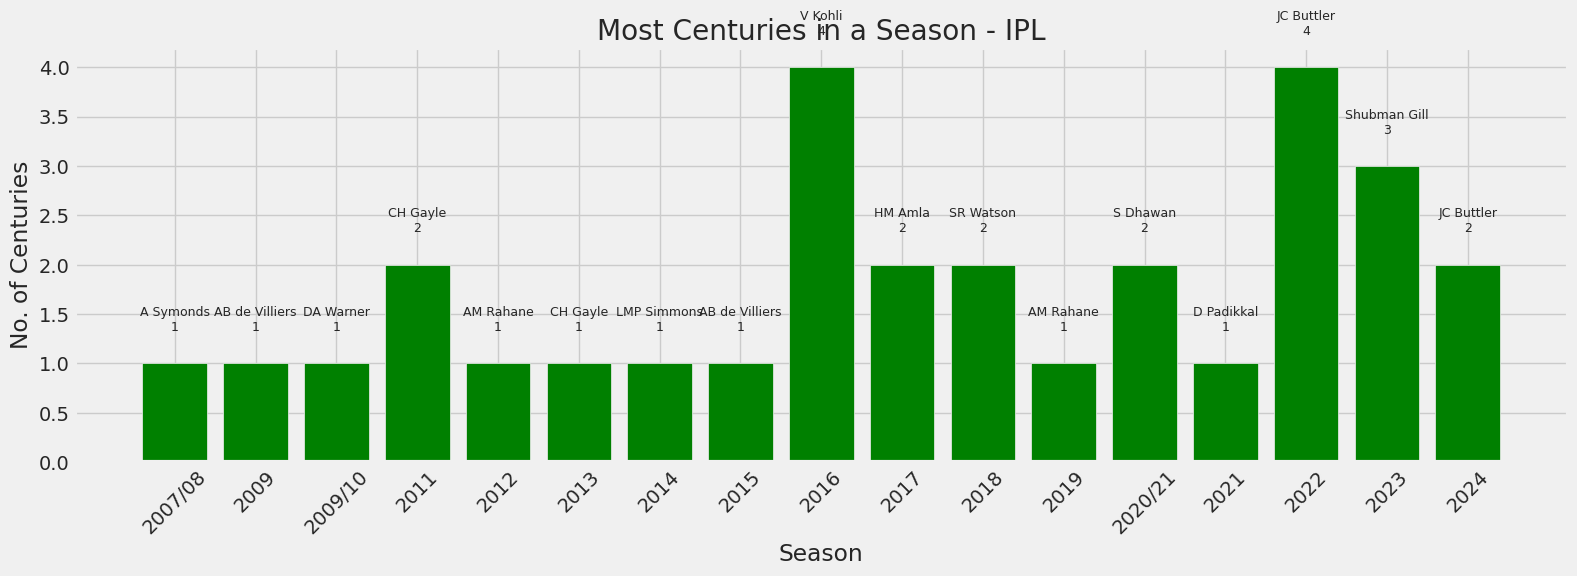

In [33]:
bat_runs = deli.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index(name='runs')
centuries = bat_runs[bat_runs['runs'] >= 100]
centuries = centuries.merge(mat[['match_id', 'season']], on='match_id', how='left')
cent_by_season = centuries.groupby(['season', 'batter']).size().reset_index(name='centuries')
max_cent = cent_by_season.sort_values(['season', 'centuries'], ascending=[True, False])
max_cent = max_cent.groupby('season').head(1).reset_index(drop=True)

plt.figure(figsize=(16,6))
bars = plt.bar(max_cent['season'].astype(str), max_cent['centuries'], color='green')
plt.title('Most Centuries in a Season - IPL')
plt.xlabel('Season')
plt.ylabel('No. of Centuries')
plt.xticks(rotation=45)

for bar, name, ct in zip(bars, max_cent['batter'], max_cent['centuries']):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{name}\n{ct}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


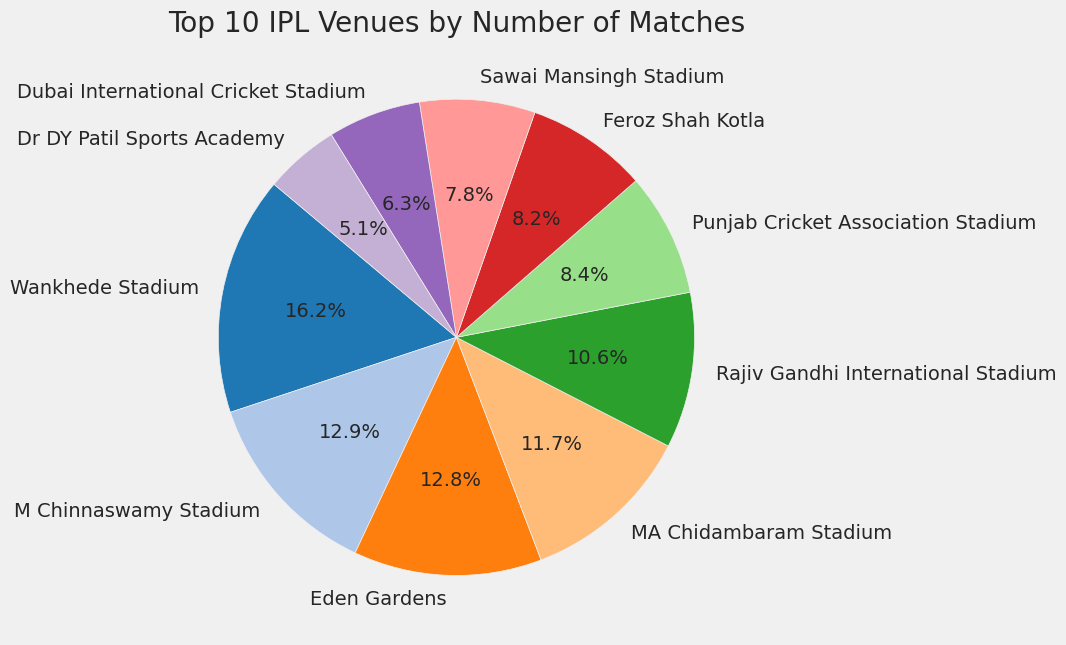

In [34]:
venue_counts = mat['venue'].value_counts().reset_index()
venue_counts.columns = ['venue', 'matches']

plt.figure(figsize=(10,10))
plt.pie(venue_counts['matches'][:10], labels=venue_counts['venue'][:10],
        autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title('Top 10 IPL Venues by Number of Matches')
plt.tight_layout()
plt.show()
